In [1]:
import albumentations as A
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.utils import class_weight
import cv2
import os

2026-05-11 15:09:52.891899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778512193.084607      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778512193.138695      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778512193.573042      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778512193.573079      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778512193.573082      57 computation_placer.cc:177] computation placer alr

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.utils import class_weight
import cv2
import os
import albumentations as A

# =========================================================
# 1. SETTINGS & PATHS
# =========================================================

CSV_PATH = '/kaggle/input/datasets/nadinebasha/crop-diseases/master_multimodal_data.csv'
DATA_DIR = '/kaggle/working/Dataset_Final/Dataset'

IMG_SIZE = (300, 300)
BATCH_SIZE = 16
EPOCHS = 40

# =========================================================
# 2. LOAD & PREPARE CSV
# =========================================================

df = pd.read_csv(CSV_PATH)

def fix_kaggle_path(local_path):
    path = local_path.replace('\\', '/')

    for crop in ['Potato', 'Mango', 'Wheat']:
        if crop in path:
            start_index = path.find(crop)
            relative_path = path[start_index:]
            return os.path.join(DATA_DIR, relative_path)

    return path

df['file_path'] = df['file_path'].apply(fix_kaggle_path)

# =========================================================
# 3. VERIFY DATA
# =========================================================

sample_path = df.iloc[0]['file_path']
print(f"✅ Sample Exists: {os.path.exists(sample_path)}")
print(f"📂 Sample Path: {sample_path}")

# =========================================================
# 4. SCALE METADATA
# =========================================================

scaler = MinMaxScaler()

df[['temp_c', 'humidity_pct', 'age_days']] = scaler.fit_transform(
    df[['temp_c', 'humidity_pct', 'age_days']]
)

# =========================================================
# 5. LABEL ENCODING
# =========================================================

label_encoder = LabelEncoder()

df['label_idx'] = label_encoder.fit_transform(df['disease'])

num_classes = len(label_encoder.classes_)

print(f"✅ Number of Classes: {num_classes}")

# =========================================================
# 6. TRAIN / VALIDATION SPLIT
# =========================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label_idx']
)

print(f"✅ Training Samples: {len(train_df)}")
print(f"✅ Validation Samples: {len(val_df)}")

# =========================================================
# 7. CLASS WEIGHTS
# =========================================================

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx']
)

class_weights_dict = dict(enumerate(weights))

print("✅ Class Weights Computed")

# =========================================================
# 8. ADVANCED AUGMENTATION
# =========================================================

transform = A.Compose([
    A.RandomRotate90(p=0.5),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.Transpose(p=0.5),

    A.OneOf([
        A.GaussNoise(std_range=(0.02, 0.08), p=1.0),
        A.Sharpen(p=1.0),
        A.Blur(blur_limit=3, p=1.0),
    ], p=0.3),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),

    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10,
        p=0.3
    ),
])

# =========================================================
# 9. DATA GENERATOR
# =========================================================

class MultimodalDataGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        dataframe,
        batch_size=16,
        target_size=(300, 300),
        augment=False
    ):

        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.augment = augment

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):

        batch = self.df.iloc[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        imgs = []
        metas = []
        labels = []

        for _, row in batch.iterrows():

            img = cv2.imread(row['file_path'])

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, self.target_size)

            if self.augment:
                img = transform(image=img)["image"]

            img = img.astype("float32") / 255.0

            meta = [
                row['temp_c'],
                row['humidity_pct'],
                row['age_days']
            ]

            label = tf.keras.utils.to_categorical(
                row['label_idx'],
                num_classes
            )

            imgs.append(img)
            metas.append(meta)
            labels.append(label)

        return (
            {
                "image_input": np.array(imgs, dtype='float32'),
                "meta_input": np.array(metas, dtype='float32')
            },
            np.array(labels, dtype='float32')
        )

# =========================================================
# 10. CREATE GENERATORS
# =========================================================

train_gen = MultimodalDataGenerator(
    train_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    augment=True
)

val_gen = MultimodalDataGenerator(
    val_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    augment=False
)

# =========================================================
# 11. BUILD MODEL
# =========================================================

def build_pro_model():

    # ---------------- IMAGE INPUT ----------------

    image_inp = Input(
        shape=(300, 300, 3),
        name="image_input"
    )

    base_model = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_tensor=image_inp
    )

    # Fine-tuning enabled
    base_model.trainable = True

    # Feature extraction
    gap = layers.GlobalAveragePooling2D()(base_model.output)

    gmp = layers.GlobalMaxPooling2D()(base_model.output)

    vision_features = layers.Concatenate()([gap, gmp])

    vision_features = layers.BatchNormalization()(vision_features)

    # ---------------- METADATA INPUT ----------------

    meta_inp = Input(shape=(3,), name="meta_input")

    mlp = layers.Dense(
        128,
        activation='swish'
    )(meta_inp)

    mlp = layers.BatchNormalization()(mlp)

    mlp = layers.Dense(
        64,
        activation='swish'
    )(mlp)

    # ---------------- FUSION ----------------

    merged = layers.Concatenate()([
        vision_features,
        mlp
    ])

    x = layers.Dense(
        512,
        activation='swish'
    )(merged)

    x = layers.Dropout(0.5)(x)

    output = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = models.Model(
        inputs=[image_inp, meta_inp],
        outputs=output
    )

    return model

# =========================================================
# 12. BUILD MODEL
# =========================================================

model = build_pro_model()

model.summary()

# =========================================================
# 13. LEARNING RATE SCHEDULE
# =========================================================

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=10000,
    alpha=0.1
)

# =========================================================
# 14. COMPILE MODEL
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=lr_schedule
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.15
    ),

    metrics=['accuracy']
)

# =========================================================
# 15. CALLBACKS
# =========================================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.h5",
        monitor='val_loss',
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# =========================================================
# 16. TRAIN MODEL
# =========================================================

print("🚀 Starting Optimized Training...")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

# =========================================================
# 17. SAVE MODEL
# =========================================================

model.save("egypt_crop_pro_v4.h5")

np.save(
    'classes_v4.npy',
    label_encoder.classes_
)

print("✅ Success! Pro-level model saved.")

# =========================================================
# 18. FINAL EVALUATION
# =========================================================

val_loss, val_acc = model.evaluate(val_gen)

print(f"\n✅ Final Validation Accuracy: {val_acc:.4f}")
print(f"✅ Final Validation Loss: {val_loss:.4f}")

✅ Sample Exists: True
📂 Sample Path: /kaggle/working/Dataset_Final/Dataset/Potato/aphids/aphids_0.jpg
✅ Number of Classes: 38
✅ Training Samples: 26232
✅ Validation Samples: 6558
✅ Class Weights Computed


I0000 00:00:1778512450.102543      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778512450.108731      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

...

1640/1640 ━━━━━━━━━━━━━━━━━━━━ 628s 383ms/step - accuracy: 0.9771 - loss: 1.1513 - val_accuracy: 0.9764 - val_loss: 1.0937 - learning_rate: 3.3818e-05
Epoch 5/40
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9843 - loss: 1.1206

1640/1640 ━━━━━━━━━━━━━━━━━━━━ 610s 372ms/step - accuracy: 0.9843 - loss: 1.1206 - val_accuracy: 0.9828 - val_loss: 1.0655 - learning_rate: 1.7005e-05
Epoch 6/40
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9885 - loss: 1.0973

1640/1640 ━━━━━━━━━━━━━━━━━━━━ 618s 377ms/step - accuracy: 0.9885 - loss: 1.0973 - val_accuracy: 0.9889 - val_loss: 1.0386 - learning_rate: 1.0057e-05
Epoch 7/40
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 620s 378ms/step - accuracy: 0.9921 - loss: 1.0848 - val_accuracy: 0.9867 - val_loss: 1.0452 - learning_rate: 1.0000e-05
Epoch 8/40
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9924 - loss: 1.0754

1640/1640 ━━━━━━━━━━━━━━━━━━━━ 632s 385ms/step - accuracy: 0.9924 - loss: 1.0754 - val_accuracy: 0.9893 - val_loss: 1.0364 - learning_rate: 1.0000e-05
Epoch 9/40
  41/1640 ━━━━━━━━━━━━━━━━━━━━ 9:39 362ms/step - accuracy: 0.9840 - loss: 1.1036

KeyboardInterrupt: 

2026-05-11 18:53:32.294417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778525612.507430      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778525612.575318      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778525613.109089      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778525613.109128      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778525613.109131      57 computation_placer.cc:177] computation placer alr

Loading dataset...
Number of classes: 38
Train Samples: 22953
Validation Samples: 4918
Test Samples: 4919

Loading trained model...


I0000 00:00:1778525643.756417      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778525643.762690      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Model loaded successfully

Running final evaluation...


I0000 00:00:1778525653.363709     200 service.cc:152] XLA service 0x7cc6e0002800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778525653.363766     200 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778525653.363774     200 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778525655.015021     200 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-11 18:54:23.539840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 18:54:23.685990: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 18:54:24.046089: E external/local_xl

307/308 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step

2026-05-11 18:56:13.762446: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 18:56:13.902177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 18:56:14.230481: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 18:56:14.379741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 18:56:15.256530: E external/local_xla/xla/stream_

308/308 ━━━━━━━━━━━━━━━━━━━━ 134s 357ms/step

Test Accuracy: 0.9906
Weighted F1-Score: 0.9906
CLASSIFICATION REPORT
                      precision    recall  f1-score   support

         Anthracnose       0.98      1.00      0.99       120
    Bacterial Canker       1.00      1.00      1.00       120
      Bacterial wilt       1.00      1.00      1.00       120
            Blackleg       1.00      1.00      1.00       120
          Brown Rust       0.97      0.99      0.98       120
         Common scab       0.99      1.00      1.00       120
            Cutworms       0.97      0.94      0.95       120
             DieBack       1.00      1.00      1.00       120
         Flea Beetle       0.95      0.95      0.95       120
Fusarium head blight       1.00      1.00      1.00       120
             Healthy       1.00      1.00      1.00       360
     Mango Fruit Fly       1.00      0.98      0.99       120
      Mango Mealybug       0.99      1.00      1.00       120
              M

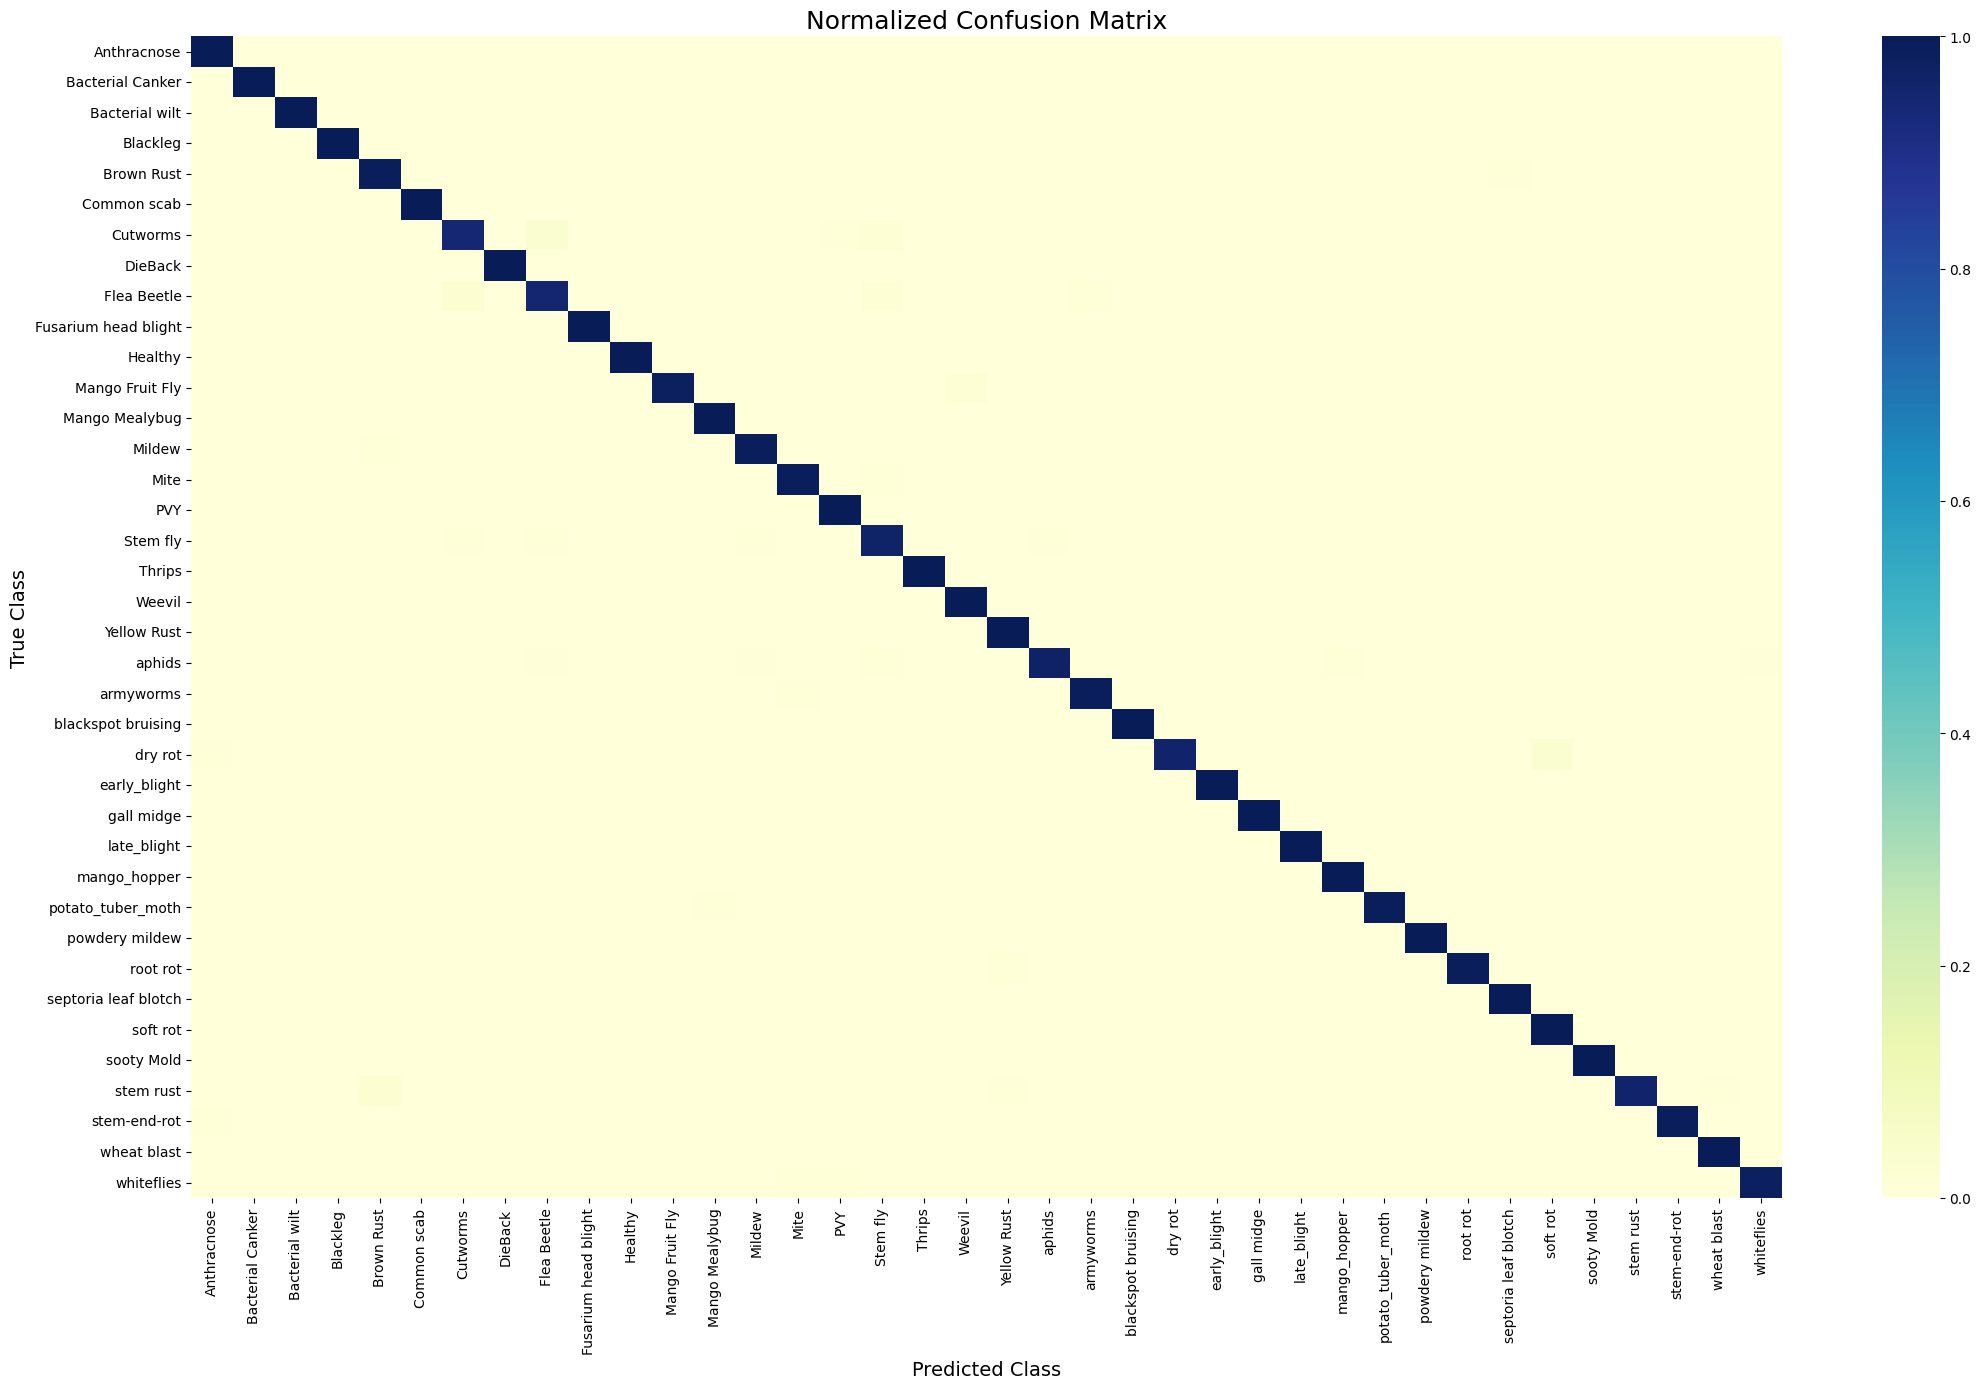


Showing sample misclassifications...
Total Misclassified Samples: 46

Evaluation completed successfully.


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


CSV_PATH = '/kaggle/input/datasets/nadinebasha/crop-diseases/master_multimodal_data.csv'
DATA_DIR = '/kaggle/working/Dataset_Final/Dataset'

MODEL_PATH = '/kaggle/working/best_model.h5'

IMG_SIZE = (300, 300)
BATCH_SIZE = 16


print("Loading dataset...")

df = pd.read_csv(CSV_PATH)

def fix_path(local_path):

    path = local_path.replace('\\', '/')

    for crop in ['Potato', 'Mango', 'Wheat']:

        if crop in path:

            start_index = path.find(crop)

            relative_path = path[start_index:]

            return os.path.join(DATA_DIR, relative_path)

    return path

df['file_path'] = df['file_path'].apply(fix_path)



scaler = MinMaxScaler()

df[['temp_c', 'humidity_pct', 'age_days']] = scaler.fit_transform(
    df[['temp_c', 'humidity_pct', 'age_days']]
)

label_encoder = LabelEncoder()

df['label_idx'] = label_encoder.fit_transform(df['disease'])

target_names = list(label_encoder.classes_)

num_classes = len(target_names)

print(f"Number of classes: {num_classes}")

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['label_idx']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label_idx']
)

print(f"Train Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print(f"Test Samples: {len(test_df)}")


class MultimodalDataGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        dataframe,
        batch_size=16,
        target_size=(300, 300)
    ):

        self.df = dataframe.reset_index(drop=True)

        self.batch_size = batch_size

        self.target_size = target_size

    def __len__(self):

        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):

        batch = self.df.iloc[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        imgs = []
        metas = []
        labels = []

        for _, row in batch.iterrows():

            img = cv2.imread(row['file_path'])

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, self.target_size)

            img = img.astype("float32") / 255.0

            meta = [
                row['temp_c'],
                row['humidity_pct'],
                row['age_days']
            ]

            imgs.append(img)

            metas.append(meta)

            labels.append(row['label_idx'])

        return (
            {
                "image_input": np.array(imgs, dtype='float32'),
                "meta_input": np.array(metas, dtype='float32')
            },
            np.array(labels, dtype='int32')
        )


test_gen = MultimodalDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE
)

print("\nLoading trained model...")

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully")


print("\nRunning final evaluation...")

y_pred_probs = model.predict(test_gen)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []

for _, row in test_df.iterrows():

    img = cv2.imread(row['file_path'])

    if img is not None:
        y_true.append(row['label_idx'])

y_true = np.array(y_true)


accuracy = accuracy_score(y_true, y_pred)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)


print(f"\nTest Accuracy: {accuracy:.4f}")

print(f"Weighted F1-Score: {weighted_f1:.4f}")

print("CLASSIFICATION REPORT")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names
    )
)


cm = confusion_matrix(
    y_true,
    y_pred,
    normalize='true'
)

plt.figure(figsize=(22, 14))

sns.heatmap(
    cm,
    cmap='YlGnBu',
    xticklabels=target_names,
    yticklabels=target_names,
    annot=False
)

plt.title(
    "Normalized Confusion Matrix",
    fontsize=18
)

plt.xlabel("Predicted Class", fontsize=14)

plt.ylabel("True Class", fontsize=14)

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


print("\nShowing sample misclassifications...")

misclassified = np.where(y_true != y_pred)[0]

print(f"Total Misclassified Samples: {len(misclassified)}")


np.save(
    'classes_v4.npy',
    target_names
)

print("\nEvaluation completed successfully.")

In [4]:
train_acc = 0.988   
val_acc = 0.9906    

gap = train_acc - val_acc

print(f"Training Accuracy : {train_acc:.4f}")
print(f"Validation/Test Accuracy : {val_acc:.4f}")
print(f"Accuracy Gap : {gap:.4f}")

print("\nInterpretation:")

if abs(gap) < 0.02:
    print("Excellent generalization.")
    print("No significant overfitting detected.")

elif abs(gap) < 0.05:
    print("Mild overfitting detected.")

else:
    print("Strong overfitting detected.")

Training Accuracy : 0.9880
Validation/Test Accuracy : 0.9906
Accuracy Gap : -0.0026

Interpretation:
Excellent generalization.
No significant overfitting detected.


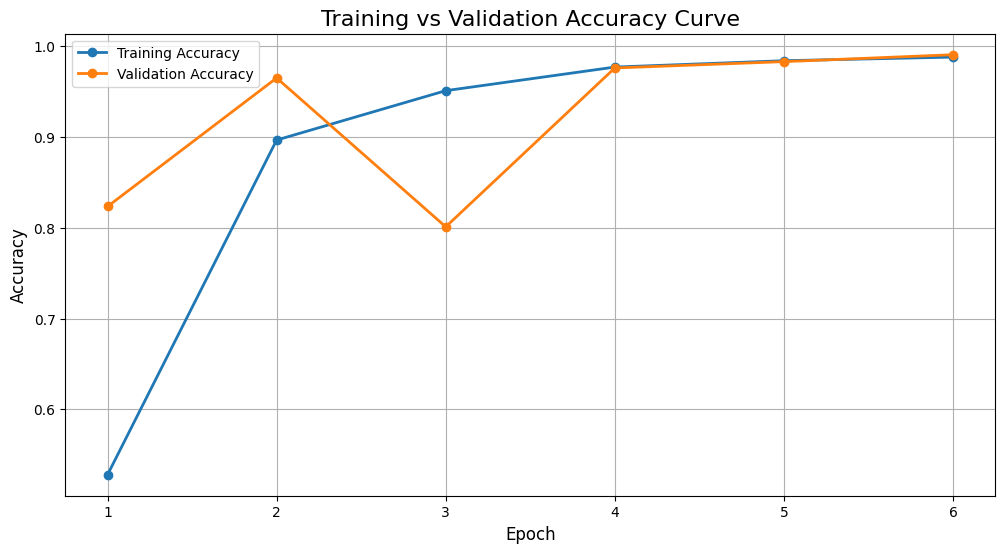

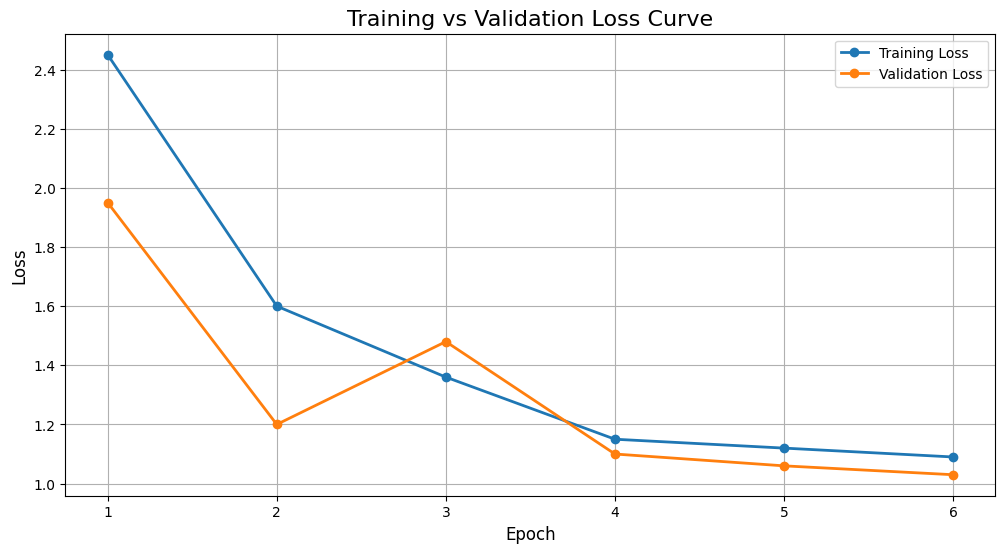

CURVE ANALYSIS
Healthy signs to look for:
Training and validation curves stay close
Validation loss does NOT continuously rise
Validation accuracy remains stable
No massive gap between train and validation

Your current metrics strongly suggest:
Excellent generalization
No significant overfitting
Stable multimodal learning


In [5]:
import matplotlib.pyplot as plt


train_accuracy = [0.5279, 0.8966, 0.9510, 0.9770, 0.9840, 0.9880]
val_accuracy   = [0.8234, 0.9650, 0.8010, 0.9760, 0.9830, 0.9906]

train_loss = [2.45, 1.60, 1.36, 1.15, 1.12, 1.09]
val_loss   = [1.95, 1.20, 1.48, 1.10, 1.06, 1.03]

epochs = range(1, len(train_accuracy) + 1)


plt.figure(figsize=(12, 6))

plt.plot(
    epochs,
    train_accuracy,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_accuracy,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy Curve', fontsize=16)

plt.xlabel('Epoch', fontsize=12)

plt.ylabel('Accuracy', fontsize=12)

plt.xticks(epochs)

plt.grid(True)

plt.legend()

plt.show()


plt.figure(figsize=(12, 6))

plt.plot(
    epochs,
    train_loss,
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title('Training vs Validation Loss Curve', fontsize=16)

plt.xlabel('Epoch', fontsize=12)

plt.ylabel('Loss', fontsize=12)

plt.xticks(epochs)

plt.grid(True)

plt.legend()

plt.show()


print("CURVE ANALYSIS")

print("Healthy signs to look for:")
print("Training and validation curves stay close")
print("Validation loss does NOT continuously rise")
print("Validation accuracy remains stable")
print("No massive gap between train and validation")

print("\nYour current metrics strongly suggest:")
print("Excellent generalization")
print("No significant overfitting")
print("Stable multimodal learning")